In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
%matplotlib inline
from pandas import DataFrame
import numpy as np
import pandas as pd

In [2]:
nsim = 10

In [3]:
ser5_dist = pd.read_table('/data/mcohen3/CTD/asparagine/s5n7/analysis/ser5_dist/dat/ser5_dist_all.dat', sep = r'\s+')
phos_ser5_dist = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/analysis/ser5_dist/dat/ser5_OG_dist_all.dat', sep = r'\s+')

In [4]:
ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/asparagine/s5n7/reweighting/weights_by_frame_MC-order10.dat', header=None)
p_ctd_weights_combined_raw = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/reweighting/weights_by_frame_MC-order10.dat', header=None)

In [5]:
ctd_weights_combined = ctd_weights_combined_raw/ctd_weights_combined_raw.sum()
p_ctd_weights_combined = p_ctd_weights_combined_raw/p_ctd_weights_combined_raw.sum()

In [6]:
ser5_dist.head()

,#Frame,SER5-SER12,SER12-SER19,SER5-SER19
0,1,15.5858,16.9706,31.6968
1,2,16.1167,16.5015,31.7230
2,3,15.9991,16.6463,31.6598
3,4,16.8166,16.1890,32.0318
4,5,16.6687,15.9435,31.8960


In [7]:
phos_ser5_dist.head()

,#Frame,SEP5-SEP12,SEP12-SEP19,SEP5-SEP19
0,1,15.4833,15.1399,23.4018
1,2,15.4334,15.1517,23.2040
2,3,15.4751,15.4969,23.3249
3,4,15.4541,15.5712,23.2287
4,5,15.6608,15.6838,23.4145


In [8]:
ser5_dist.mean()

#Frame         2.450000e+07
SER5-SER12     1.450539e+01
SER12-SER19    1.545369e+01
SER5-SER19     1.942788e+01
dtype: float64

In [9]:
phos_ser5_dist.mean()

#Frame         2.450000e+07
SEP5-SEP12     1.732679e+01
SEP12-SEP19    1.779573e+01
SEP5-SEP19     2.385479e+01
dtype: float64

In [10]:
ser5_dist['weights'] = ctd_weights_combined
phos_ser5_dist['weights'] = p_ctd_weights_combined

In [11]:
ser5_dist

,#Frame,SER5-SER12,SER12-SER19,SER5-SER19,weights
0,1,15.5858,16.9706,31.6968,5.568765e-09
1,2,16.1167,16.5015,31.7230,1.472184e-08
2,3,15.9991,16.6463,31.6598,9.697759e-09
3,4,16.8166,16.1890,32.0318,3.353217e-08
4,5,16.6687,15.9435,31.8960,8.338822e-09
...,...,...,...,...,...
48999995,48999996,11.5763,12.6714,23.9691,1.317516e-08
48999996,48999997,11.9246,12.6483,24.1849,1.811567e-08
48999997,48999998,12.0334,12.2005,23.6625,3.887373e-08
48999998,48999999,12.2300,12.3063,23.8635,2.536682e-08


## Looking at overall average distances

In [13]:
def weighted_mean_and_se(values, weights):
    """
    Calculates the weighted mean and its standard error.

    Args:
        values (array-like): The data values.
        weights (array-like): The corresponding weights for each value.

    Returns:
        tuple: A tuple containing the weighted mean and the standard error of the weighted mean.
    """
    values = np.array(values)
    weights = np.array(weights)

    if len(values) != len(weights):
        raise ValueError("Values and weights must have the same length.")

    # Create a boolean mask to find non-NaN values in both data and weights.
    valid_mask = ~np.isnan(values) & ~np.isnan(weights)
    
    # Filter the data and weights to keep only valid entries.
    valid_data = values[valid_mask]
    valid_weights = weights[valid_mask]

    # Calculate the weighted mean
    weighted_mean = np.average(valid_data, weights=valid_weights)

    # Calculate the weighted variance
    # For sample variance, adjust for degrees of freedom (n-1)
    # The denominator for weighted variance is typically sum(weights) - (sum(weights^2) / sum(weights))
    # or a simpler form for large samples. Here we use a common form for sample weighted variance.
    sum_of_weights = np.sum(valid_weights)
    weighted_variance = np.sum(valid_weights * (valid_data - weighted_mean)**2) / (sum_of_weights - (np.sum(valid_weights**2) / sum_of_weights))

    # Calculate the standard error of the weighted mean
    # SE = sqrt(weighted_variance / effective_sample_size)
    # Effective sample size can be considered as (sum_of_weights)^2 / sum(weights^2)
    effective_sample_size = (sum_of_weights**2) / np.sum(valid_weights**2)
    standard_error = np.sqrt(weighted_variance / effective_sample_size)

    return weighted_mean, standard_error

In [14]:
ser5_dist_sim_list = np.array_split(ser5_dist, nsim)
phos_ser5_dist_sim_list = np.array_split(phos_ser5_dist, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [15]:
# Define column names
columns = ['SER5-SER12', 'SER12-SER19', 'SER5-SER19']

# Create an empty DataFrame with 2 rows and 5 columns
ser5_dist_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)
ser5_dist_weights = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(ser5_dist_all)

   SER5-SER12  SER12-SER19  SER5-SER19
0         NaN          NaN         NaN
1         NaN          NaN         NaN
2         NaN          NaN         NaN
3         NaN          NaN         NaN
4         NaN          NaN         NaN
5         NaN          NaN         NaN
6         NaN          NaN         NaN
7         NaN          NaN         NaN
8         NaN          NaN         NaN
9         NaN          NaN         NaN


In [16]:
i = 0
for sim in ser5_dist_sim_list:
        
    weights = sim['weights'].sum()

    mean = sim.iloc[:,1:4].mul(sim['weights'], 0).sum()/weights

    ser5_dist_all.loc[i] = mean
    ser5_dist_weights.loc[i] = weights
    
    i += 1

In [17]:
ser5_dist_weights

,SER5-SER12,SER12-SER19,SER5-SER19
0,0.092297,0.092297,0.092297
1,0.092335,0.092335,0.092335
2,0.092769,0.092769,0.092769
3,0.092761,0.092761,0.092761
4,0.093030,0.093030,0.093030
5,0.107129,0.107129,0.107129
6,0.107626,0.107626,0.107626
7,0.107512,0.107512,0.107512
8,0.107195,0.107195,0.107195
9,0.107347,0.107347,0.107347


In [19]:
mean_list = []
sem_list = []
for i in range(3):
    print(i)
    mean_list.append(weighted_mean_and_se(ser5_dist_all.iloc[:,i].tolist(), ser5_dist_weights.iloc[:,i].tolist())[0])
    sem_list.append(weighted_mean_and_se(ser5_dist_all.iloc[:,i].tolist(), ser5_dist_weights.iloc[:,i].tolist())[1])

0
1
2


In [20]:
df_with_mean = pd.concat([ser5_dist_all, pd.DataFrame([mean_list], index=['mean'], columns=columns)])
ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_list], index=['sem'], columns=columns)])

In [21]:
ser_dist_overall = ser5_dist_all_final.copy()

In [22]:
# Define column names
columns = ['SEP5-SEP12', 'SEP12-SEP19', 'SEP5-SEP19']

# Create an empty DataFrame with 2 rows and 5 columns
phos_ser5_dist_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)
phos_ser5_dist_weights = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(phos_ser5_dist_all)

   SEP5-SEP12  SEP12-SEP19  SEP5-SEP19
0         NaN          NaN         NaN
1         NaN          NaN         NaN
2         NaN          NaN         NaN
3         NaN          NaN         NaN
4         NaN          NaN         NaN
5         NaN          NaN         NaN
6         NaN          NaN         NaN
7         NaN          NaN         NaN
8         NaN          NaN         NaN
9         NaN          NaN         NaN


In [23]:
i = 0
for sim in phos_ser5_dist_sim_list:
        
    weights = sim['weights'].sum()

    mean = sim.iloc[:,1:4].mul(sim['weights'], 0).sum()/weights

    phos_ser5_dist_all.loc[i] = mean
    phos_ser5_dist_weights.loc[i] = weights
    
    i += 1

In [24]:
phos_ser5_dist_weights

,SEP5-SEP12,SEP12-SEP19,SEP5-SEP19
0,0.102873,0.102873,0.102873
1,0.103984,0.103984,0.103984
2,0.103693,0.103693,0.103693
3,0.103112,0.103112,0.103112
4,0.103085,0.103085,0.103085
5,0.096667,0.096667,0.096667
6,0.096336,0.096336,0.096336
7,0.096843,0.096843,0.096843
8,0.097146,0.097146,0.097146
9,0.096261,0.096261,0.096261


In [26]:
mean_list = []
sem_list = []
for i in range(3):
    print(i)
    mean_list.append(weighted_mean_and_se(phos_ser5_dist_all.iloc[:,i].tolist(), phos_ser5_dist_weights.iloc[:,i].tolist())[0])
    sem_list.append(weighted_mean_and_se(phos_ser5_dist_all.iloc[:,i].tolist(), phos_ser5_dist_weights.iloc[:,i].tolist())[1])

0
1
2


In [27]:
df_with_mean = pd.concat([phos_ser5_dist_all, pd.DataFrame([mean_list], index=['mean'], columns=columns)])
phos_ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_list], index=['sem'], columns=columns)])

In [28]:
phos_ser_dist_overall = phos_ser5_dist_all_final.copy()

## Looking at when Pro6 is in turn

In [25]:
params = [{'sep':r'\s+', 'low_memory':False}, {'engine':'c'}][0]

ctd_secstruc = pd.read_table('/data/mcohen3/CTD/asparagine/s5n7/analysis/turn/ctd_sec.out', **params)
ctd_phos_secstruc = pd.read_table('/data/mcohen3/CTD/asparagine/ps5n7/analysis/turn/ctd_p_sec.out', **params)

In [26]:
ser5_dist['Pro:13'] = ctd_secstruc['PRO:14']
phos_ser5_dist['Pro:13'] = ctd_phos_secstruc['PRO:14']

In [27]:
ser5_dist

,#Frame,SER5-SER12,SER12-SER19,SER5-SER19,weights,Pro:13
0,1,15.5858,16.9706,31.6968,5.568765e-09,0
1,2,16.1167,16.5015,31.7230,1.472184e-08,0
2,3,15.9991,16.6463,31.6598,9.697759e-09,0
3,4,16.8166,16.1890,32.0318,3.353217e-08,0
4,5,16.6687,15.9435,31.8960,8.338822e-09,0
...,...,...,...,...,...,...
48999995,48999996,11.5763,12.6714,23.9691,1.317516e-08,0
48999996,48999997,11.9246,12.6483,24.1849,1.811567e-08,0
48999997,48999998,12.0334,12.2005,23.6625,3.887373e-08,0
48999998,48999999,12.2300,12.3063,23.8635,2.536682e-08,0


In [28]:
ser5_dist_sim_list = np.array_split(ser5_dist, nsim)
phos_ser5_dist_sim_list = np.array_split(phos_ser5_dist, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [29]:
# Define column names
columns = ['SER5-SER12', 'SER12-SER19', 'SER5-SER19']

# Create an empty DataFrame with 2 rows and 5 columns
ser5_dist_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(ser5_dist_all)

   SER5-SER12  SER12-SER19  SER5-SER19
0         NaN          NaN         NaN
1         NaN          NaN         NaN
2         NaN          NaN         NaN
3         NaN          NaN         NaN
4         NaN          NaN         NaN
5         NaN          NaN         NaN
6         NaN          NaN         NaN
7         NaN          NaN         NaN
8         NaN          NaN         NaN
9         NaN          NaN         NaN


In [30]:
i = 0
for sim in ser5_dist_sim_list:
        
    weights = ((sim['Pro:13'] == 'T')*sim['weights']).sum()

    mean = sim.iloc[:,1:4].mul((sim['Pro:13'] == 'T')*sim['weights'], 0).sum()/weights

    ser5_dist_all.loc[i] = mean
    
    i += 1

In [31]:
ser5_dist_all

,SER5-SER12,SER12-SER19,SER5-SER19
0,14.652893,15.155652,16.360378
1,15.386932,14.860881,18.242638
2,14.454950,16.006753,16.062269
3,15.181456,14.854794,16.069548
4,14.973690,14.181039,17.213006
5,15.156991,14.937380,15.971990
6,14.407463,14.585404,19.346068
7,13.401788,15.683254,15.745636
8,15.332801,14.784557,18.662922
9,15.262035,14.664544,18.164543


In [32]:
# Calculate the SEM (standard error of the mean)
mean_values = ser5_dist_all.mean()
sem_values = ser5_dist_all.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([ser5_dist_all, pd.DataFrame([mean_values], index=['mean'])])
ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [33]:
ser_dist_pro6_turn = ser5_dist_all_final.copy()

In [34]:
# Define column names
columns = ['SEP5-SEP12', 'SEP12-SEP19', 'SEP5-SEP19']

# Create an empty DataFrame with 2 rows and 5 columns
phos_ser5_dist_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(phos_ser5_dist_all)

   SEP5-SEP12  SEP12-SEP19  SEP5-SEP19
0         NaN          NaN         NaN
1         NaN          NaN         NaN
2         NaN          NaN         NaN
3         NaN          NaN         NaN
4         NaN          NaN         NaN
5         NaN          NaN         NaN
6         NaN          NaN         NaN
7         NaN          NaN         NaN
8         NaN          NaN         NaN
9         NaN          NaN         NaN


In [35]:
i = 0
for sim in phos_ser5_dist_sim_list:
        
    weights = ((sim['Pro:13'] == 'T')*sim['weights']).sum()

    mean = sim.iloc[:,1:4].mul((sim['Pro:13'] == 'T')*sim['weights'], 0).sum()/weights

    phos_ser5_dist_all.loc[i] = mean
    
    i += 1

In [36]:
phos_ser5_dist_all

,SEP5-SEP12,SEP12-SEP19,SEP5-SEP19
0,17.038245,15.941331,21.718475
1,16.427121,17.224644,22.331598
2,17.461469,16.920566,22.672968
3,17.046730,15.986873,22.172799
4,17.712199,17.003379,21.344835
5,18.282667,17.571649,23.664181
6,17.904809,17.711855,22.359197
7,17.541445,18.004922,21.667374
8,18.181189,17.820512,21.439391
9,17.712427,17.659310,21.473558


In [37]:
# Calculate the SEM (standard error of the mean)
mean_values = phos_ser5_dist_all.mean()
sem_values = phos_ser5_dist_all.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([phos_ser5_dist_all, pd.DataFrame([mean_values], index=['mean'])])
phos_ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [38]:
phos_ser_dist_pro6_turn = phos_ser5_dist_all_final.copy()

## Looking at when Pro3 is in turn

In [39]:
ser5_dist['Pro:10'] = ctd_secstruc['PRO:11']
phos_ser5_dist['Pro:10'] = ctd_phos_secstruc['PRO:11']

In [40]:
ser5_dist_sim_list = np.array_split(ser5_dist, nsim)
phos_ser5_dist_sim_list = np.array_split(phos_ser5_dist, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [41]:
# Define column names
columns = ['SER5-SER12', 'SER12-SER19', 'SER5-SER19']

# Create an empty DataFrame with 2 rows and 5 columns
ser5_dist_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(ser5_dist_all)

   SER5-SER12  SER12-SER19  SER5-SER19
0         NaN          NaN         NaN
1         NaN          NaN         NaN
2         NaN          NaN         NaN
3         NaN          NaN         NaN
4         NaN          NaN         NaN
5         NaN          NaN         NaN
6         NaN          NaN         NaN
7         NaN          NaN         NaN
8         NaN          NaN         NaN
9         NaN          NaN         NaN


In [42]:
i = 0
for sim in ser5_dist_sim_list:
        
    weights = ((sim['Pro:10'] == 'T')*sim['weights']).sum()

    mean = sim.iloc[:,1:4].mul((sim['Pro:10'] == 'T')*sim['weights'], 0).sum()/weights

    ser5_dist_all.loc[i] = mean
    
    i += 1

In [43]:
ser5_dist_all

,SER5-SER12,SER12-SER19,SER5-SER19
0,11.158194,15.160196,16.704573
1,12.198312,15.639418,17.213182
2,11.799278,15.908982,15.742999
3,12.118068,15.268783,16.861646
4,12.527691,15.648305,17.250950
5,11.504831,14.904004,16.625671
6,11.688008,14.823975,16.899530
7,11.312871,16.307938,18.032934
8,12.087067,16.366016,17.866634
9,11.892848,15.019967,17.947049


In [44]:
# Calculate the SEM (standard error of the mean)
mean_values = ser5_dist_all.mean()
sem_values = ser5_dist_all.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([ser5_dist_all, pd.DataFrame([mean_values], index=['mean'])])
ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [45]:
ser_dist_pro3_turn = ser5_dist_all_final.copy()

In [46]:
# Define column names
columns = ['SEP5-SEP12', 'SEP12-SEP19', 'SEP5-SEP19']

# Create an empty DataFrame with 2 rows and 5 columns
phos_ser5_dist_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(phos_ser5_dist_all)

   SEP5-SEP12  SEP12-SEP19  SEP5-SEP19
0         NaN          NaN         NaN
1         NaN          NaN         NaN
2         NaN          NaN         NaN
3         NaN          NaN         NaN
4         NaN          NaN         NaN
5         NaN          NaN         NaN
6         NaN          NaN         NaN
7         NaN          NaN         NaN
8         NaN          NaN         NaN
9         NaN          NaN         NaN


In [47]:
i = 0
for sim in phos_ser5_dist_sim_list:
        
    weights = ((sim['Pro:10'] == 'T')*sim['weights']).sum()

    mean = sim.iloc[:,1:4].mul((sim['Pro:10'] == 'T')*sim['weights'], 0).sum()/weights

    phos_ser5_dist_all.loc[i] = mean
    
    i += 1

In [48]:
phos_ser5_dist_all

,SEP5-SEP12,SEP12-SEP19,SEP5-SEP19
0,14.438767,14.258259,19.301329
1,14.495725,18.604313,20.969063
2,14.509267,17.805580,22.347478
3,14.046348,17.401644,22.199692
4,15.370652,17.728993,20.482349
5,14.542760,17.937655,22.556167
6,15.780454,18.569278,21.585307
7,15.164052,18.932405,21.912405
8,15.873300,17.835471,19.844402
9,15.521068,18.619309,19.898348


In [49]:
# Calculate the SEM (standard error of the mean)
mean_values = phos_ser5_dist_all.mean()
sem_values = phos_ser5_dist_all.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([phos_ser5_dist_all, pd.DataFrame([mean_values], index=['mean'])])
phos_ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [50]:
phos_ser_dist_pro3_turn = phos_ser5_dist_all_final.copy()

Current dimensions: 6.4 x 4.8 inches
New dimensions: 3.25 x 2.4374999999999996 inches


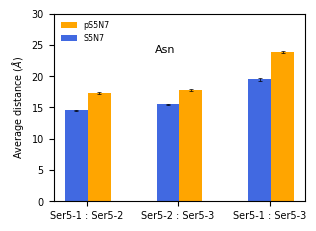

In [29]:
plt.figure()

x = ["Ser5-1 : Ser5-2","Ser5-2 : Ser5-3","Ser5-1 : Ser5-3"]

x_axis = np.arange(len(x))

plt.bar(x_axis + 0.14, phos_ser_dist_overall.loc['mean'], 0.25, yerr = phos_ser_dist_overall.loc['sem'], error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, label='pS5N7', color='orange')
plt.bar(x_axis - 0.11, ser_dist_overall.loc['mean'], 0.25, yerr = ser_dist_overall.loc['sem'], error_kw={'elinewidth': 0.5, "capsize": 1.5, "capthick": 0.5}, label='S5N7', color='royalblue')
plt.xticks(x_axis, x, fontsize = 7)
plt.yticks(fontsize = 7)
plt.legend(loc = "upper left", fontsize = 5.75, frameon=False)
plt.ylabel("Average distance ($\AA$)", fontsize = 7)
plt.ylim(top=30)  
plt.ylim(bottom=0)
#plt.title("Overall")
plt.text(0.75, 25, 'Asn', fontsize=8, verticalalignment='top')

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 3.25

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('ser5_distances_asn.png', dpi=300, bbox_inches='tight')

plt.show()

Text(0.5, 1.0, 'Pro6 in Turn')

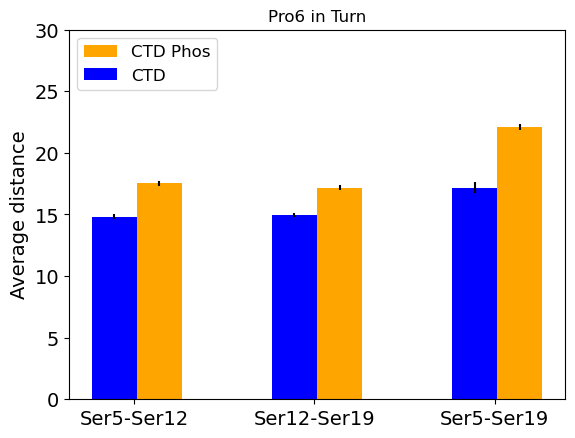

In [52]:
x = ["Ser5-Ser12","Ser12-Ser19","Ser5-Ser19"]

x_axis = np.arange(len(x))

plt.bar(x_axis + 0.14, phos_ser_dist_pro6_turn.loc['mean'], 0.25, yerr = phos_ser_dist_pro6_turn.loc['sem'], label='CTD Phos', color='orange')
plt.bar(x_axis - 0.11, ser_dist_pro6_turn.loc['mean'], 0.25, yerr = ser_dist_pro6_turn.loc['sem'], label='CTD', color='blue')
plt.xticks(x_axis, x, fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc = "upper left", fontsize = 12)
plt.ylabel("Average distance", fontsize = 14)
plt.ylim(top=30)  
plt.ylim(bottom=0)
plt.title("Pro6 in Turn")

Text(0.5, 1.0, 'Pro3 in Turn')

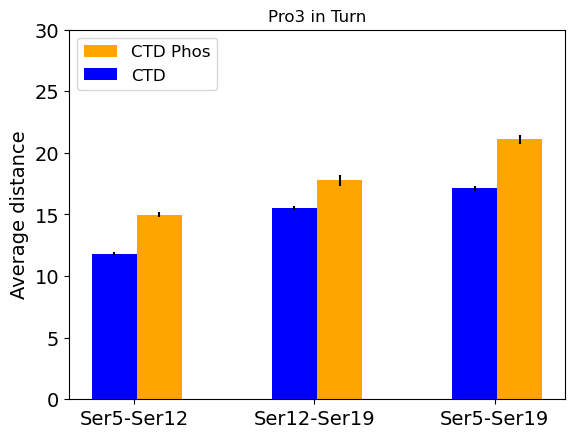

In [53]:
x = ["Ser5-Ser12","Ser12-Ser19","Ser5-Ser19"]

x_axis = np.arange(len(x))

plt.bar(x_axis + 0.14, phos_ser_dist_pro3_turn.loc['mean'], 0.25, yerr = phos_ser_dist_pro3_turn.loc['sem'], label='CTD Phos', color='orange')
plt.bar(x_axis - 0.11, ser_dist_pro3_turn.loc['mean'], 0.25, yerr = ser_dist_pro3_turn.loc['sem'], label='CTD', color='blue')
plt.xticks(x_axis, x, fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc = "upper left", fontsize = 12)
plt.ylabel("Average distance", fontsize = 14)
plt.ylim(top=30)  
plt.ylim(bottom=0)
plt.title("Pro3 in Turn")

# Comparing with no turn

## Pro6 no turn

In [54]:
ser5_dist_sim_list = np.array_split(ser5_dist, nsim)
phos_ser5_dist_sim_list = np.array_split(phos_ser5_dist, nsim)

/cm/shared/apps/anaconda3/python3.12/lib/python3.12/site-packages/numpy/core/fromnumeric.py:59: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [55]:
# Define column names
columns = ['SER5-SER12', 'SER12-SER19', 'SER5-SER19']

# Create an empty DataFrame with 2 rows and 5 columns
ser5_dist_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(ser5_dist_all)

   SER5-SER12  SER12-SER19  SER5-SER19
0         NaN          NaN         NaN
1         NaN          NaN         NaN
2         NaN          NaN         NaN
3         NaN          NaN         NaN
4         NaN          NaN         NaN
5         NaN          NaN         NaN
6         NaN          NaN         NaN
7         NaN          NaN         NaN
8         NaN          NaN         NaN
9         NaN          NaN         NaN


In [56]:
i = 0
for sim in ser5_dist_sim_list:
        
    weights = ((sim['Pro:13'] != 'T')*sim['weights']).sum()

    mean = sim.iloc[:,1:4].mul((sim['Pro:13'] != 'T')*sim['weights'], 0).sum()/weights

    ser5_dist_all.loc[i] = mean
    
    i += 1

In [57]:
# Calculate the SEM (standard error of the mean)
mean_values = ser5_dist_all.mean()
sem_values = ser5_dist_all.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([ser5_dist_all, pd.DataFrame([mean_values], index=['mean'])])
ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [58]:
ser_dist_pro6_noturn = ser5_dist_all_final.copy()

In [59]:
# Define column names
columns = ['SEP5-SEP12', 'SEP12-SEP19', 'SEP5-SEP19']

# Create an empty DataFrame with 2 rows and 5 columns
phos_ser5_dist_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(phos_ser5_dist_all)

   SEP5-SEP12  SEP12-SEP19  SEP5-SEP19
0         NaN          NaN         NaN
1         NaN          NaN         NaN
2         NaN          NaN         NaN
3         NaN          NaN         NaN
4         NaN          NaN         NaN
5         NaN          NaN         NaN
6         NaN          NaN         NaN
7         NaN          NaN         NaN
8         NaN          NaN         NaN
9         NaN          NaN         NaN


In [60]:
i = 0
for sim in phos_ser5_dist_sim_list:
        
    weights = ((sim['Pro:13'] != 'T')*sim['weights']).sum()

    mean = sim.iloc[:,1:4].mul((sim['Pro:13'] != 'T')*sim['weights'], 0).sum()/weights

    phos_ser5_dist_all.loc[i] = mean
    
    i += 1

In [61]:
# Calculate the SEM (standard error of the mean)
mean_values = phos_ser5_dist_all.mean()
sem_values = phos_ser5_dist_all.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([phos_ser5_dist_all, pd.DataFrame([mean_values], index=['mean'])])
phos_ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [62]:
phos_ser_dist_pro6_noturn = phos_ser5_dist_all_final.copy()

## Pro3 no turn

In [63]:
# Define column names
columns = ['SER5-SER12', 'SER12-SER19', 'SER5-SER19']

# Create an empty DataFrame with 2 rows and 5 columns
ser5_dist_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(ser5_dist_all)

   SER5-SER12  SER12-SER19  SER5-SER19
0         NaN          NaN         NaN
1         NaN          NaN         NaN
2         NaN          NaN         NaN
3         NaN          NaN         NaN
4         NaN          NaN         NaN
5         NaN          NaN         NaN
6         NaN          NaN         NaN
7         NaN          NaN         NaN
8         NaN          NaN         NaN
9         NaN          NaN         NaN


In [64]:
i = 0
for sim in ser5_dist_sim_list:
        
    weights = ((sim['Pro:10'] != 'T')*sim['weights']).sum()

    mean = sim.iloc[:,1:4].mul((sim['Pro:10'] != 'T')*sim['weights'], 0).sum()/weights

    ser5_dist_all.loc[i] = mean
    
    i += 1

In [65]:
# Calculate the SEM (standard error of the mean)
mean_values = ser5_dist_all.mean()
sem_values = ser5_dist_all.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([ser5_dist_all, pd.DataFrame([mean_values], index=['mean'])])
ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [66]:
ser_dist_pro3_noturn = ser5_dist_all_final.copy()

In [67]:
# Define column names
columns = ['SEP5-SEP12', 'SEP12-SEP19', 'SEP5-SEP19']

# Create an empty DataFrame with 2 rows and 5 columns
phos_ser5_dist_all = pd.DataFrame(np.nan, index=range(nsim), columns=columns)

print(phos_ser5_dist_all)

   SEP5-SEP12  SEP12-SEP19  SEP5-SEP19
0         NaN          NaN         NaN
1         NaN          NaN         NaN
2         NaN          NaN         NaN
3         NaN          NaN         NaN
4         NaN          NaN         NaN
5         NaN          NaN         NaN
6         NaN          NaN         NaN
7         NaN          NaN         NaN
8         NaN          NaN         NaN
9         NaN          NaN         NaN


In [68]:
i = 0
for sim in phos_ser5_dist_sim_list:
        
    weights = ((sim['Pro:10'] != 'T')*sim['weights']).sum()

    mean = sim.iloc[:,1:4].mul((sim['Pro:10'] != 'T')*sim['weights'], 0).sum()/weights

    phos_ser5_dist_all.loc[i] = mean
    
    i += 1

In [69]:
# Calculate the SEM (standard error of the mean)
mean_values = phos_ser5_dist_all.mean()
sem_values = phos_ser5_dist_all.sem()

# Append as a new row labeled 'sem'
df_with_mean = pd.concat([phos_ser5_dist_all, pd.DataFrame([mean_values], index=['mean'])])
phos_ser5_dist_all_final = pd.concat([df_with_mean, pd.DataFrame([sem_values], index=['sem'])])

In [70]:
phos_ser_dist_pro3_noturn = phos_ser5_dist_all_final.copy()

Text(0.5, 1.0, 'Phosphorylated Asn')

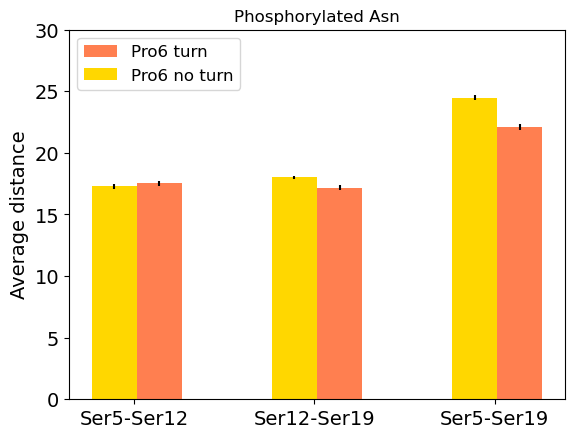

In [71]:
x = ["Ser5-Ser12","Ser12-Ser19","Ser5-Ser19"]

x_axis = np.arange(len(x))

plt.bar(x_axis + 0.14, phos_ser_dist_pro6_turn.loc['mean'], 0.25, yerr = phos_ser_dist_pro6_turn.loc['sem'], label='Pro6 turn', color='coral')
plt.bar(x_axis - 0.11, phos_ser_dist_pro6_noturn.loc['mean'], 0.25, yerr = phos_ser_dist_pro6_noturn.loc['sem'], label='Pro6 no turn', color='gold')
plt.xticks(x_axis, x, fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc = "upper left", fontsize = 12)
plt.ylabel("Average distance", fontsize = 14)
plt.ylim(top=30)  
plt.ylim(bottom=0)
plt.title("Phosphorylated Asn")

Text(0.5, 1.0, 'Phosphorylated Asn')

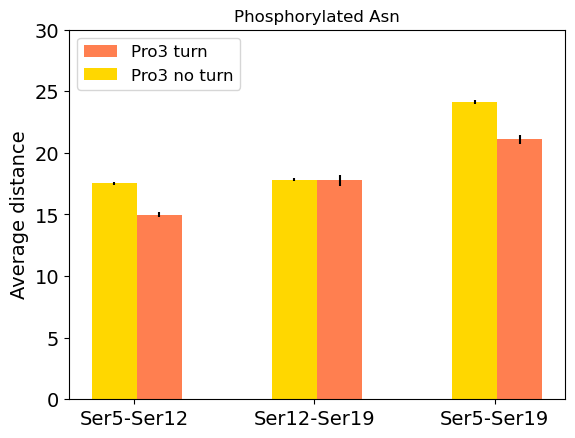

In [72]:
x = ["Ser5-Ser12","Ser12-Ser19","Ser5-Ser19"]

x_axis = np.arange(len(x))

plt.bar(x_axis + 0.14, phos_ser_dist_pro3_turn.loc['mean'], 0.25, yerr = phos_ser_dist_pro3_turn.loc['sem'], label='Pro3 turn', color='coral')
plt.bar(x_axis - 0.11, phos_ser_dist_pro3_noturn.loc['mean'], 0.25, yerr = phos_ser_dist_pro3_noturn.loc['sem'], label='Pro3 no turn', color='gold')
plt.xticks(x_axis, x, fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc = "upper left", fontsize = 12)
plt.ylabel("Average distance", fontsize = 14)
plt.ylim(top=30)  
plt.ylim(bottom=0)
plt.title("Phosphorylated Asn")

Text(0.5, 1.0, 'Unphosphorylated Asn')

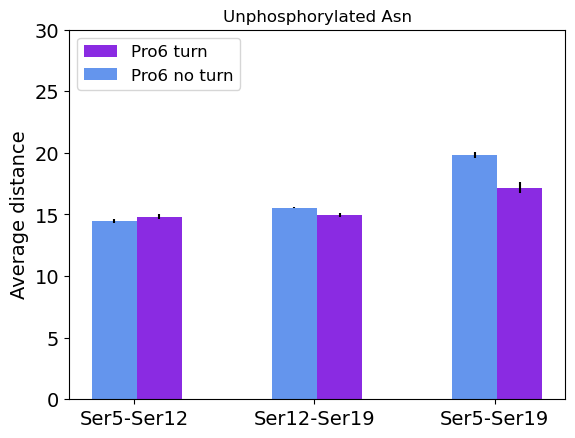

In [73]:
x = ["Ser5-Ser12","Ser12-Ser19","Ser5-Ser19"]

x_axis = np.arange(len(x))

plt.bar(x_axis + 0.14, ser_dist_pro6_turn.loc['mean'], 0.25, yerr = ser_dist_pro6_turn.loc['sem'], label='Pro6 turn', color='blueviolet')
plt.bar(x_axis - 0.11, ser_dist_pro6_noturn.loc['mean'], 0.25, yerr = ser_dist_pro6_noturn.loc['sem'], label='Pro6 no turn', color='cornflowerblue')
plt.xticks(x_axis, x, fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc = "upper left", fontsize = 12)
plt.ylabel("Average distance", fontsize = 14)
plt.ylim(top=30)  
plt.ylim(bottom=0)
plt.title("Unphosphorylated Asn")

Text(0.5, 1.0, 'Unphosphorylated Asn')

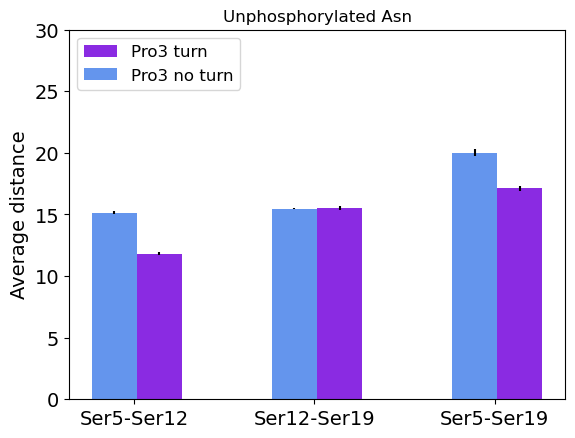

In [74]:
x = ["Ser5-Ser12","Ser12-Ser19","Ser5-Ser19"]

x_axis = np.arange(len(x))

plt.bar(x_axis + 0.14, ser_dist_pro3_turn.loc['mean'], 0.25, yerr = ser_dist_pro3_turn.loc['sem'], label='Pro3 turn', color='blueviolet')
plt.bar(x_axis - 0.11, ser_dist_pro3_noturn.loc['mean'], 0.25, yerr = ser_dist_pro3_noturn.loc['sem'], label='Pro3 no turn', color='cornflowerblue')
plt.xticks(x_axis, x, fontsize = 14)
plt.yticks(fontsize = 14)
plt.legend(loc = "upper left", fontsize = 12)
plt.ylabel("Average distance", fontsize = 14)
plt.ylim(top=30)  
plt.ylim(bottom=0)
plt.title("Unphosphorylated Asn")